<a href="https://colab.research.google.com/github/mokhivibes/ml_course_courseworks/blob/main/HousePriceReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
sns.set_theme(style='whitegrid')


In [13]:
df = pd.read_csv('/content/df_clean_HOUSE_PRICE.csv')
num_cols = df.select_dtypes(include='number')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1399 non-null   int64  
 1   MSZoning       1399 non-null   object 
 2   LotFrontage    1399 non-null   float64
 3   LotArea        1399 non-null   int64  
 4   Street         1399 non-null   object 
 5   LotShape       1399 non-null   object 
 6   LandContour    1399 non-null   object 
 7   Utilities      1399 non-null   object 
 8   LotConfig      1399 non-null   object 
 9   LandSlope      1399 non-null   object 
 10  Neighborhood   1399 non-null   object 
 11  Condition1     1399 non-null   object 
 12  Condition2     1399 non-null   object 
 13  BldgType       1399 non-null   object 
 14  HouseStyle     1399 non-null   object 
 15  OverallQual    1399 non-null   int64  
 16  OverallCond    1399 non-null   int64  
 17  YearBuilt      1399 non-null   int64  
 18  YearRemo

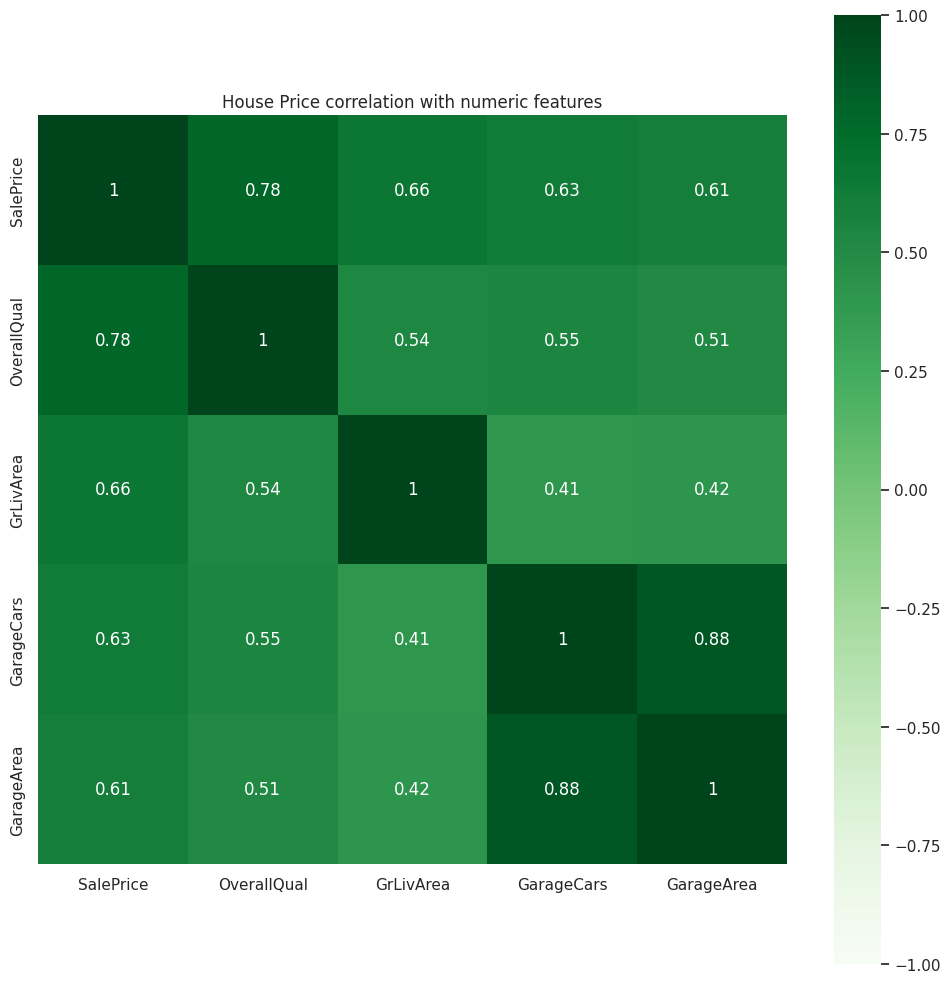

In [41]:
corr_matrix = num_cols.corr()['SalePrice'].sort_values(ascending=False)
top_5_cols = corr_matrix.head(5).index
corr_matrix2 = num_cols[top_5_cols].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_matrix2,
    annot=True,
    cmap='Greens',
    vmin=-1,
    vmax=1,
    square=True
)

plt.title('House Price correlation with numeric features')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)


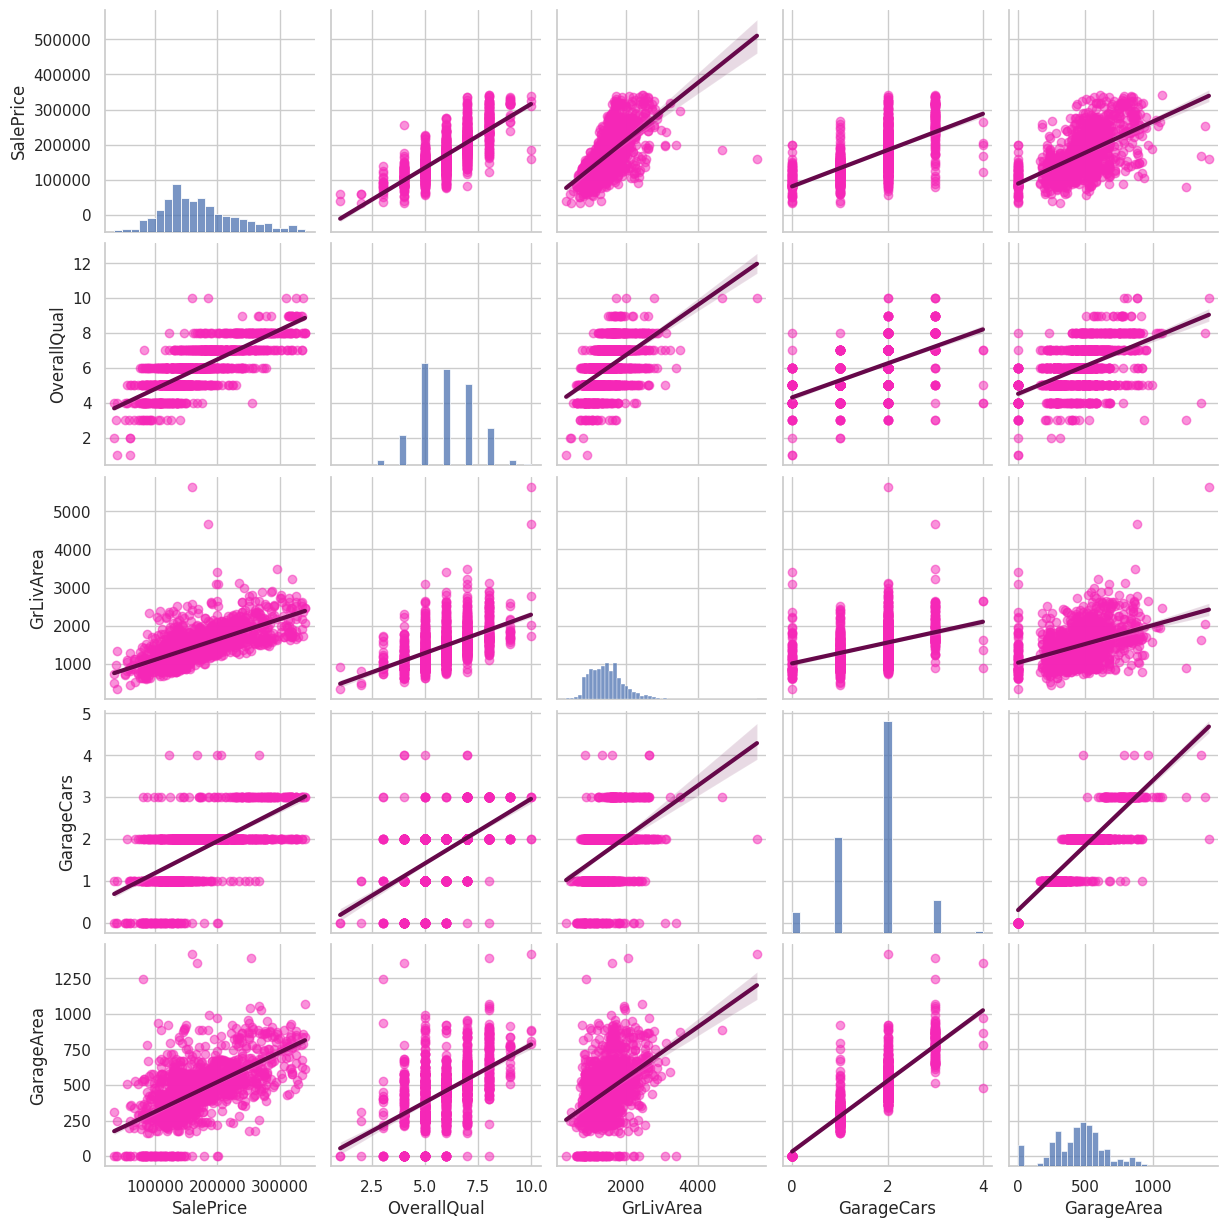

In [47]:
sns.pairplot(
    data=df[top_5_cols],
    diag_kind='hist',
    kind='reg',
    palette='Greens',
    plot_kws={'line_kws': {'color': '#66084A', 'lw': 3}, 'scatter_kws': {'alpha': 0.5, 'color': '#F527B7'}}
)


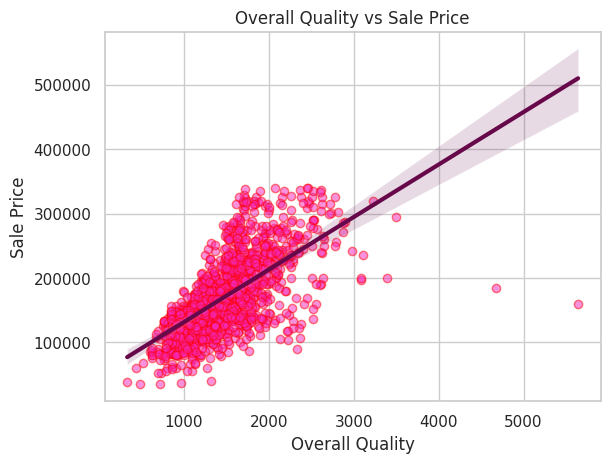

In [36]:
sns.regplot(
    data=df,
    x='GrLivArea',
    y='SalePrice',
    line_kws={'color': '#66084A', 'lw':3},
    ci=95,
    scatter_kws={'alpha':0.5, 'color': '#F527B7', 'edgecolor':'red'},
)

plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()